<a href="https://colab.research.google.com/github/ishume94/OpticalCircs/blob/main/OpticalCircuits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx
!pip install tqdm

#State generation
Over here we show how to define the quantum state generator, based on a Graph. The Graph encodes all the relevant information of the quantum state produced, and can be translated into different optic experiments (Bulk Optics, Integrated Photonics or Entanglement by Path identity). The state can be written as \\
$\phi(w)\approx \sum_m\frac{1}{m!}\left(\sum_{E(G)}w(E)x^\dagger(E)y^\dagger(E)\right)^m$
with G being the graph, E the edge of the graph and $x^\dagger$ a creation operator of a photon in path $x$. Each of the edges will have a color associated to the mode number of the photon on that path. As example for 4 paths (a,b) and 2 modes (0 and 1) a potential state is \\
$\phi(w)= \sum_m\frac{1}{m!}\left(w_{a,b}^{0,0}a_0^\dagger b_0^\dagger + w_{c,d}^{0,0}c_0^\dagger d_0^\dagger + w_{a,c}^{1,1}a_1^\dagger c_1^\dagger  + w_{b,d}^{1,1}b_1^\dagger d_1^\dagger \right)^m  $

For this reason we want to encode this into a graph, which may have potentially more than 1 edge (Correlated Photon pairs) between 2 nodes (Optical paths). As example we will produce the graph with 4 weighted edges, 4 optical paths and it's complete version.

Edge (a, b): color=0, weight=(2+3j)
Edge (a, c): color=1, weight=(1-1j)
Edge (b, d): color=1, weight=(1+1j)
Edge (c, d): color=0, weight=(4+2j)


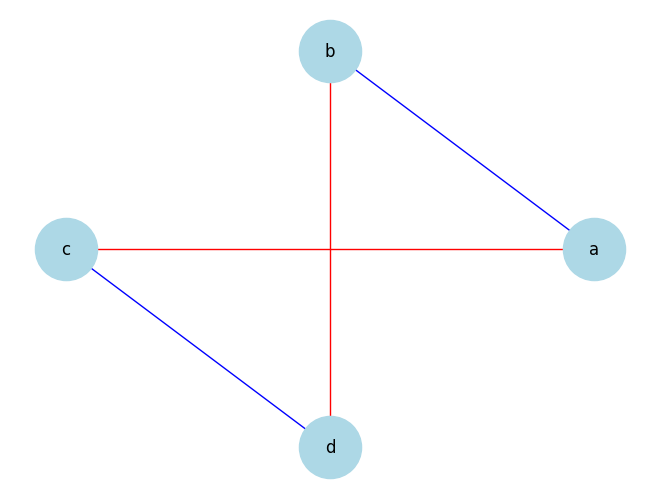

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

#Initial simple empty graph.
G = nx.Graph()
# Add nodes
optical_paths = ['a', 'b', 'c', 'd']
G.add_nodes_from(optical_paths)
#For plotting
color_mapping = {'blue': 0, 'red': 1, 'green': 2, 'yellow': 3, 'purple': 4}
# Define edges with attributes
edges = [
    ('a', 'b', {'color': 0, 'w': 2 + 3j}),
    ('a', 'c', {'color': 1, 'w': 1 - 1j}),
    ('d', 'c', {'color': 0, 'w': 4 + 2j}),
    ('d', 'b', {'color': 1, 'w': 1 + 1j})
]

# Add edges with attributes
G.add_edges_from(edges)

# Verifying edges with attributes
for u, v, data in G.edges(data=True):
    print(f"Edge ({u}, {v}): color={data['color']}, weight={data['w']}")

# Draw the graph
pos = nx.circular_layout(G)
edge_colors = [list(color_mapping.keys())[list(color_mapping.values()).index(data['color'])] for _, _, data in G.edges(data=True)]
nx.draw(G, pos, with_labels=True, edge_color=edge_colors, node_color='lightblue', node_size=2000, font_size=12)
plt.show()


In [ ]:
#If you want to take out the weights from each of the edges to compute the Fidelity:
w_values = [data['w'] for _, _, data in G.edges(data=True)]
print(f"Weights for each edge in the same order they were appended {w_values}")
#And if you want the edges from a particular optical path (Info of entangled photons)
print("Edges connected to node 'a':")
for neighbor in G.neighbors('a'):
    data = G['a'][neighbor]
    print(f"Edge (a, {neighbor}): color={data['color']}, w={data['w']}")

#If you want the specific data for an edge you can do
print(f"Data for edge ('a', 'b'): {G['a']['b']}")
print(f"Color for edge ('a', 'b'): {G['a']['b']['color']}")
print(f"Weight for edge ('a', 'b'): {G['a']['b']['w']}")


Weights for each edge in the same order they were appended [(2+3j), (1-1j), (1+1j), (4+2j)]
Edges connected to node 'a':
Edge (a, b): color=0, w=(2+3j)
Edge (a, c): color=1, w=(1-1j)
Data for edge ('a', 'b'): {'color': 0, 'w': (2+3j)}
Color for edge ('a', 'b'): 0
Weight for edge ('a', 'b'): (2+3j)


Now, we potentially want to generate multiple edges for very complex target states. In that case we want to use a multigraph instead. We will produce the complete graph for the 4 optical path system. For this purpose, the type of object needs to change. Now we are dealing with a MultiGraph, the colors of the edge will be appended as a tuple.

In [ ]:
import itertools as it
#For plotting
def draw_labeled_multigraph(G, attr_name, ax=None):
    """
    Draws a MultiGraph with multi-edges (multiple edges between nodes) and labels the edges
    based on an attribute (e.g., 'w' for weight, 'colors'). Each edge has two colors in this example.
    Based on the example https://networkx.org/documentation/stable/auto_examples/drawing/plot_multigraphs.html
    """
    # Define color mapping for two colors per edge
    color_mapping = {0: 'blue', 1: 'red', 2: 'green', 3: 'yellow', 4: 'purple'}
    #Tried to plot each edge with 2 colors but could not do it. It is better to print the label.
    connectionstyle = [f"arc3,rad={r}" for r in it.accumulate([0.15] * 4)]

    pos = nx.circular_layout(G)  # You can change the layout if needed
    nx.draw_networkx_nodes(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=12, ax=ax)
    nx.draw_networkx_edges(
        G, pos, edge_color="grey", connectionstyle=connectionstyle, ax=ax
    )

    # Prepare edge labels
    labels = {
        tuple(edge): f"{edge}, {attr_name}:{attrs[attr_name]}"
        for *edge, attrs in G.edges(keys=True, data=True)
    }
    #labels
    nx.draw_networkx_edge_labels(
        G,
        pos,
        labels,
        connectionstyle=connectionstyle,
        label_pos=0.3,
        font_color="blue",
        bbox={"alpha": 0},
        ax=ax,
    )

Edge (a, b) [0]: colors=(0, 0), w=(4+20j)
Edge (a, b) [1]: colors=(0, 1), w=(6-9j)
Edge (a, b) [2]: colors=(1, 0), w=(1-1j)
Edge (a, b) [3]: colors=(0, 0), w=(4+2j)
Edge (a, c) [0]: colors=(0, 0), w=(1+3j)
Edge (a, c) [1]: colors=(0, 1), w=(1-2j)
Edge (a, c) [2]: colors=(1, 0), w=(4-1j)
Edge (a, c) [3]: colors=(0, 0), w=(7+2j)
Edge (a, d) [0]: colors=(0, 0), w=(8+3j)
Edge (a, d) [1]: colors=(0, 1), w=-2j
Edge (a, d) [2]: colors=(1, 0), w=(1+0j)
Edge (a, d) [3]: colors=(0, 0), w=(4+7j)
Edge (b, c) [0]: colors=(0, 0), w=(1+4j)
Edge (b, c) [1]: colors=(0, 1), w=(3-1j)
Edge (b, c) [2]: colors=(1, 0), w=(1-3j)
Edge (b, c) [3]: colors=(0, 0), w=(5+2j)
Edge (b, d) [0]: colors=(0, 0), w=(1+7j)
Edge (b, d) [1]: colors=(0, 1), w=(9-2j)
Edge (b, d) [2]: colors=(1, 0), w=(1-8j)
Edge (b, d) [3]: colors=(0, 0), w=(6+2j)
Edge (c, d) [0]: colors=(0, 0), w=(7+3j)
Edge (c, d) [1]: colors=(0, 1), w=(3-3j)
Edge (c, d) [2]: colors=(1, 0), w=(1-9j)
Edge (c, d) [3]: colors=(0, 0), w=(6+9j)
Edges connected to

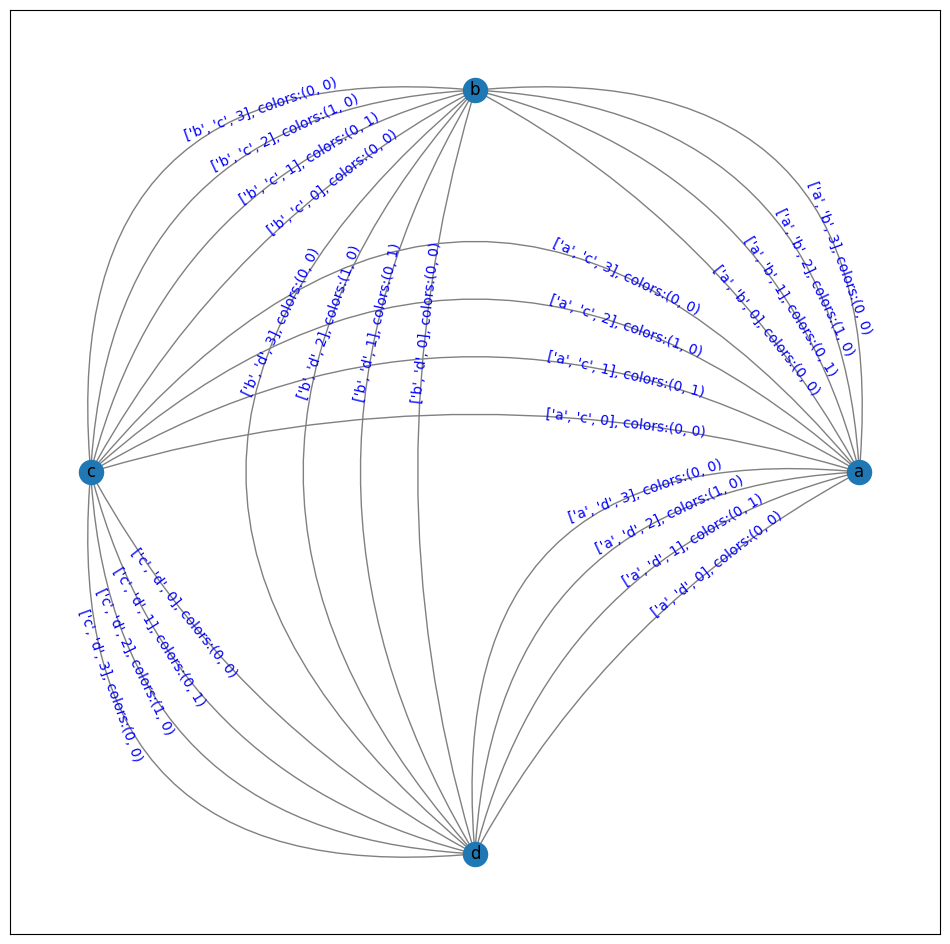

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Create an undirected multigraph
G = nx.MultiGraph()

# Add nodes
g_nodes = ['a', 'b', 'c', 'd']
G.add_nodes_from(g_nodes)

# Define color mapping
color_mapping = {0: 'blue', 1: 'red', 2: 'green', 3: 'yellow', 4: 'purple'}

# Define edges with attributes (each edge has two colors)
edges = [
    ('a', 'b', {'colors': (0, 0), 'w': 4 + 20j}),
    ('a', 'b', {'colors': (0, 1), 'w': 6 - 9j}),
    ('a', 'b', {'colors': (1, 0), 'w': 1 - 1j}),
    ('a', 'b', {'colors': (0, 0), 'w': 4 + 2j}),
    ('a', 'c', {'colors': (0, 0), 'w': 1 + 3j}),
    ('a', 'c', {'colors': (0, 1), 'w': 1 - 2j}),
    ('a', 'c', {'colors': (1, 0), 'w': 4 - 1j}),
    ('a', 'c', {'colors': (0, 0), 'w': 7 + 2j}),
    ('a', 'd', {'colors': (0, 0), 'w': 8 + 3j}),
    ('a', 'd', {'colors': (0, 1), 'w': 0 - 2j}),
    ('a', 'd', {'colors': (1, 0), 'w': 1 - 0j}),
    ('a', 'd', {'colors': (0, 0), 'w': 4 + 7j}),
    ('b', 'c', {'colors': (0, 0), 'w': 1 + 4j}),
    ('b', 'c', {'colors': (0, 1), 'w': 3 - 1j}),
    ('b', 'c', {'colors': (1, 0), 'w': 1 - 3j}),
    ('b', 'c', {'colors': (0, 0), 'w': 5 + 2j}),
    ('b', 'd', {'colors': (0, 0), 'w': 1 + 7j}),
    ('b', 'd', {'colors': (0, 1), 'w': 9 - 2j}),
    ('b', 'd', {'colors': (1, 0), 'w': 1 - 8j}),
    ('b', 'd', {'colors': (0, 0), 'w': 6 + 2j}),
    ('c', 'd', {'colors': (0, 0), 'w': 7 + 3j}),
    ('c', 'd', {'colors': (0, 1), 'w': 3 - 3j}),
    ('c', 'd', {'colors': (1, 0), 'w': 1 - 9j}),
    ('c', 'd', {'colors': (0, 0), 'w': 6 + 9j})
]

# Add edges with attributes
G.add_edges_from(edges)

# Print edges with attributes. The keys value tells the total number of edges present.
for u, v, key, data in G.edges(keys=True, data=True):
    print(f"Edge ({u}, {v}) [{key}]: colors={data['colors']}, w={data['w']}")

# Print edges connected to node 'a'
print("Edges connected to node 'a':")
for neighbor in G.neighbors('a'):
    for key in G['a'][neighbor]:
        data = G['a'][neighbor][key]
        print(f"Edge (a, {neighbor}) [{key}]: colors={data['colors']}, w={data['w']}")


# Plot the graph
fig, ax = plt.subplots(figsize=(12, 12))
#draw_labeled_multigraph(G, 'w', ax=ax) #Plots the weights
draw_labeled_multigraph(G, 'colors', ax=ax) #Plots the colors
plt.show()


In [ ]:
#Now getting the data between 2 edges gives a dictionary with the info of all the edges.")
print(f"Data for edge ('a', 'b'): {G['a']['b']}")
#To get the data for a particular key you will need to add the key, since we have multiple
print(f"Data for a particular edge ('a', 'b', [key]): {G['a']['b'][0]}")
#To get the data for either colors or weights you need to add the key or take it from the dictionary
print(f"Color for a particular edge ('a', 'b', [key]): {G['a']['b'][0]['colors']}")

Data for edge ('a', 'b'): {0: {'colors': (0, 0), 'w': (4+20j)}, 1: {'colors': (0, 1), 'w': (6-9j)}, 2: {'colors': (1, 0), 'w': (1-1j)}, 3: {'colors': (0, 0), 'w': (4+2j)}}
Data for a particular edge ('a', 'b', [key]): {'colors': (0, 0), 'w': (4+20j)}
Color for a particular edge ('a', 'b', [key]): (0, 0)


In [ ]:
GHZ = str('0000 + 1111')
print(GHZ)



1111


#Let's start training for GFlowNets
We will consider as the set of actions the addition of a weighted colored edge. Each edge contains 2 colors. We will have initially an empty graph with only nodes.

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from torch.distributions.categorical import Categorical
import random

In [ ]:
# Create an undirected multigraph
G = nx.MultiGraph()

# Add nodes
g_nodes = [0, 1, 2, 3]
G.add_nodes_from(g_nodes)
print(G)

MultiGraph with 4 nodes and 0 edges


First implementation considers only colors, since the weights need to be optimized, they are implicit on this graph.

In [ ]:
#Each training step should get a pair of colors and append them to an edge.
#We are going to follow the same procedure as with the smiling faces. Trajectory Balance
#Feature vector is the set of possible edges to generate. (2 colors)

import itertools

# Define number of nodes and colors
num_nodes = 4
num_colors = 2

# Generate all unordered node pairs (without repetition)
node_pairs = list(itertools.combinations(range(num_nodes), 2))

# Generate all possible ordered color pairs (including same colors)
color_pairs = list(itertools.product(range(num_colors), repeat=2))

# Combine each node pair with each color pair
result = [((n1, n2), (c1, c2)) for (n1, n2) in node_pairs for (c1, c2) in color_pairs]
print(len(result))
print("Edges")
print(result[0][0])
print("Colors")
print(result[0][1])

24
Edges
(0, 1)
Colors
(0, 0)


In [ ]:
FEATURE_KEYS = result
print(FEATURE_KEYS)
print(type(FEATURE_KEYS[0]))
print("FEATURE_KEYS={}".format(FEATURE_KEYS))

[((0, 1), (0, 0)), ((0, 1), (0, 1)), ((0, 1), (1, 0)), ((0, 1), (1, 1)), ((0, 2), (0, 0)), ((0, 2), (0, 1)), ((0, 2), (1, 0)), ((0, 2), (1, 1)), ((0, 3), (0, 0)), ((0, 3), (0, 1)), ((0, 3), (1, 0)), ((0, 3), (1, 1)), ((1, 2), (0, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 0)), ((1, 2), (1, 1)), ((1, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 3), (1, 0)), ((1, 3), (1, 1)), ((2, 3), (0, 0)), ((2, 3), (0, 1)), ((2, 3), (1, 0)), ((2, 3), (1, 1))]
<class 'tuple'>
FEATURE_KEYS=[((0, 1), (0, 0)), ((0, 1), (0, 1)), ((0, 1), (1, 0)), ((0, 1), (1, 1)), ((0, 2), (0, 0)), ((0, 2), (0, 1)), ((0, 2), (1, 0)), ((0, 2), (1, 1)), ((0, 3), (0, 0)), ((0, 3), (0, 1)), ((0, 3), (1, 0)), ((0, 3), (1, 1)), ((1, 2), (0, 0)), ((1, 2), (0, 1)), ((1, 2), (1, 0)), ((1, 2), (1, 1)), ((1, 3), (0, 0)), ((1, 3), (0, 1)), ((1, 3), (1, 0)), ((1, 3), (1, 1)), ((2, 3), (0, 0)), ((2, 3), (0, 1)), ((2, 3), (1, 0)), ((2, 3), (1, 1))]


In [ ]:
def set_seed(seed):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class TBModel(nn.Module):
  def __init__(self, num_hid):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Linear(len(FEATURE_KEYS), num_hid),  # len(FEATURE_KEYS) input features.
        nn.Tanh(), #nn.LeakyReLU() nn.ReLU()
        nn.Linear(num_hid, 2*len(FEATURE_KEYS)),  # 2*len(FEATURE_KEYS) outputs: len(FEATURE_KEYS) for P_F and len(FEATURE_KEYS) for P_B.
    )
    self.logZ = nn.Parameter(torch.ones(1))  # log Z is just a single number.

  def forward(self, x):
    logits = self.mlp(x)
    # Slice the logits into forward and backward policies.
    P_F = logits[..., :len(FEATURE_KEYS)]
    P_B = logits[..., len(FEATURE_KEYS):]

    return P_F, P_B

def trajectory_balance_loss(logZ, log_P_F, log_P_B, reward):
    """Trajectory balance objective converted into mean squared error loss."""
    reward=torch.tensor(reward).float()
    return (logZ + log_P_F - torch.log(torch.clamp(reward, min=1e-30)) - log_P_B).pow(2)

def state_hash(state):
    """Returns a binary hash for each submitted state."""
    return tuple([i in state for i in FEATURE_KEYS])

def state_to_tensor(state, verbose=False):
  """Encodes a state as a binary tensor (converted to float32)."""
  return torch.tensor(state_hash(state)).float()

def calculate_forward_mask_from_state(state):
    """We want to mask the sampling to avoid any potential loss of time while training.
    If the edge is already on the state, don't add it again. Avoids repeats.
    """
    mask = np.ones(len(FEATURE_KEYS))  # Allowed actions represented as 1, disallowed actions as 0.
    # Update the mask
    for i, edge in enumerate(FEATURE_KEYS):
        if edge in state:
            mask[i] = 0
    return torch.tensor(mask).bool()

def calculate_backward_mask_from_state(state):
    """Here, we mask backward actions to only select parent nodes."""
    # This mask should be 1 for any action that could have led to the current state,
    # otherwise it should be zero.
    return torch.Tensor(
        [1 if feature in state else 0 for feature in FEATURE_KEYS]
    ).bool()

def reward_f(state):
    target_state= [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))]
    reward=0
    for edge in target_state:
        if edge in state:
            reward += 1
    return reward**2
    # if set(state) == set(target_state):
    #     return 10
    # else:
    #     return 0

In [ ]:
# Fixed hyperparameters.
n_hid_units = 512
n_episodes = 10000
learning_rate = 1e-3
decay_rate = 1
seed = 69
max_edges = 4

print("For all experiments, our hyperparameters will be:")
print("    + n_hid_units={}".format(n_hid_units))
print("    + n_episodes={}".format(n_episodes))
print("    + learning_rate={}".format(learning_rate))
print("    + decay_rate={}".format(decay_rate))
print("    + seed={}".format(seed))
print("    + max_edges={}".format(max_edges))

For all experiments, our hyperparameters will be:
    + n_hid_units=512
    + n_episodes=10000
    + learning_rate=0.001
    + decay_rate=1
    + seed=69
    + max_edges=4


Training

In [ ]:
set_seed(seed)

# Instantiate model and optimizer
model = TBModel(n_hid_units)
opt = torch.optim.Adam(model.parameters(), learning_rate)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=decay_rate)

# To not complicate the code, I'll just accumulate losses here and take a
# gradient step every `update_freq` episode (at the end of each trajectory).
losses, sampled_states, logZs = [], [], []
minibatch_loss = 0
update_freq = 10

for episode in tqdm(range(n_episodes), ncols=40):
    state = []  # Each episode starts with an empty state.
    P_F_s, P_B_s = model(state_to_tensor(state))  # Forward and backward policy
    total_log_P_F, total_log_P_B = 0, 0

    for t in range(max_edges):  # All trajectories are length 2 (not including s0).
        mask = calculate_forward_mask_from_state(state)
        P_F_s = torch.where(mask, P_F_s, -100)  # Removes invalid forward actions.
        # Here P_F is logits, so we use Categorical to compute a softmax.
        #P_F_s = torch.where(torch.isnan(P_F_s), torch.full_like(P_F_s, -100), P_F_s)
        categorical = Categorical(logits=P_F_s)
        action = categorical.sample()
        new_state = state + [FEATURE_KEYS[action]] # "Go" to next state.
        total_log_P_F += categorical.log_prob(action)  # Accumulate the log_P_F sum.

        if t == max_edges-1:  # End of trajectory.
            reward = reward_f(new_state)#torch.tensor(reward(new_state)).float()
            #print(reward)
        # We recompute P_F and P_B for new_state.
        P_F_s, P_B_s = model(state_to_tensor(new_state))
        #print(new_state)
        mask = calculate_backward_mask_from_state(new_state)
        P_B_s = torch.where(mask, P_B_s, -100)  # Removes invalid backward actions.
        #P_B_s = torch.where(torch.isnan(P_B_s), torch.full_like(P_B_s, -100), P_B_s)
        total_log_P_B += Categorical(logits=P_B_s).log_prob(action)

        state = new_state  # Continue iterating.

    # We're done with the trajectory, let's compute its loss. Since the reward
    # can sometimes be zero, instead of log(0) we'll clip the log-reward to -20.
    minibatch_loss += trajectory_balance_loss(
        model.logZ,
        total_log_P_F,
        total_log_P_B,
        reward,
    )

    # We're done with the episode, add the face to the list, and if we are at an
    # update episode, take a gradient step.
    sampled_states.append(state)
    if episode % update_freq == 0:
        losses.append(minibatch_loss.item())
        logZs.append(model.logZ.item())
        minibatch_loss.backward()
        opt.step()
        opt.zero_grad()
        scheduler.step()
        minibatch_loss = 0

100%|█| 10000/10000 [01:11<00:00, 138.92


In [ ]:
ordered_states = sorted(sampled_states, key=lambda i: reward_f(i), reverse=True)
print(reward_f(ordered_states[0]))

16


In [ ]:
target_state= [((0, 1), (0, 0))] + [((0, 3), (1, 1))] + [((1, 2), (1, 1))] + [((2, 3), (0, 0))]
print(target_state)
print(ordered_states[0])
print(set(target_state))
print(set(ordered_states[0]))

[((0, 1), (0, 0)), ((0, 3), (1, 1)), ((1, 2), (1, 1)), ((2, 3), (0, 0))]
[((2, 3), (0, 0)), ((0, 3), (1, 1)), ((1, 2), (1, 1)), ((0, 1), (0, 0))]
{((0, 3), (1, 1)), ((1, 2), (1, 1)), ((2, 3), (0, 0)), ((0, 1), (0, 0))}
{((0, 3), (1, 1)), ((1, 2), (1, 1)), ((2, 3), (0, 0)), ((0, 1), (0, 0))}


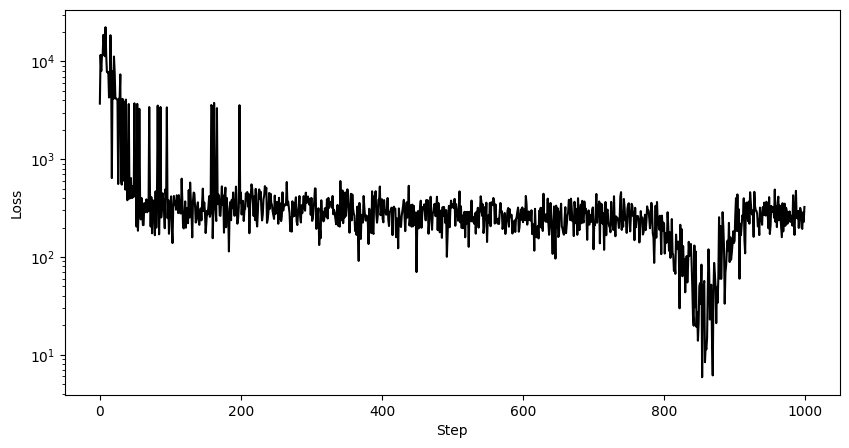

In [ ]:
def plot_loss_curve(figure, losses_A, title=""):
    filename = f"{figure}_loss.svg"
    plt.figure(figsize=(10,5))
    plt.plot(losses_A, color="black")
    plt.yscale("log")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.savefig(filename, format='svg', dpi=600)
fig_name="Loss"
plot_loss_curve(fig_name, losses, title="Loss over Training Iterations")

Text(0.5, 0.98, 'Loss and Estimated Partition Function for the Trajectory Balance Model')

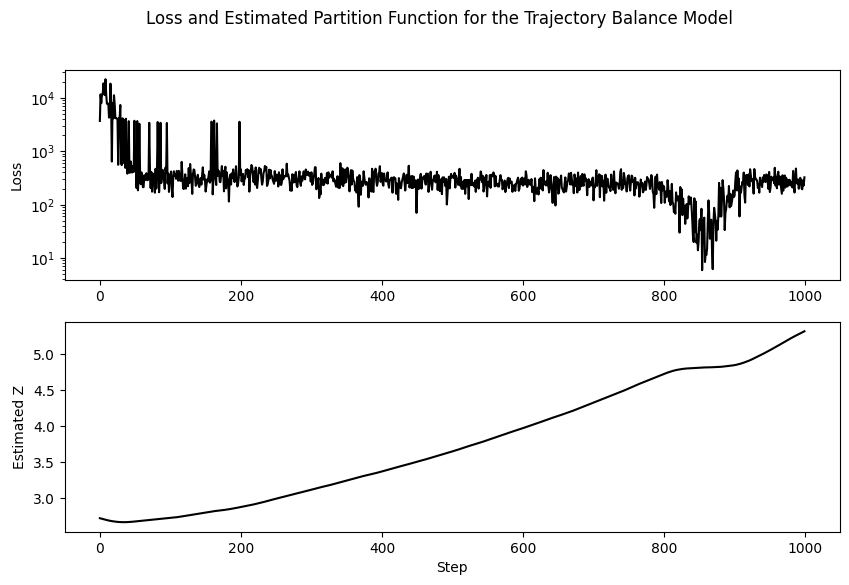

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plt.sca(ax[0])
plt.plot(losses, color="black")
plt.yscale('log')
plt.ylabel('Loss')
plt.sca(ax[1])
plt.plot(np.exp(logZs), color="black")
plt.ylabel('Estimated Z');
plt.xlabel('Step')
plt.suptitle("Loss and Estimated Partition Function for the Trajectory Balance Model")

In [ ]:
print(scheduler.get_last_lr())

[0.001]
